# SleepPy Extraction Review

This notebook reviews first-pass sleep metric extraction from Oura Ring 4 finger, Oura Ring 3 toe, Samsung Watch / SleepWatch, Muse, and OSCAR/SleepScope sample screenshots or PDFs.

**Disclaimer:** This is exploratory wellness data analysis only. It is not medical diagnosis, treatment advice, or a replacement for clinician review.

## Workflow

1. Place 1-2 representative files per device under `data/raw/samples/<device>/`.
2. Run the extraction cell to create `data/processed/nightly_summary.csv`, `data/processed/device_observations_long.csv`, and `outputs/extraction_report.md`.
3. Review extracted values, missingness, confidence labels, and trend plots.
4. Correct low-confidence or missing values manually before treating them as analysis inputs.

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd

# Reload local modules so an already-running notebook kernel picks up edits from disk.
import sleeppy.schema as sleep_schema
import sleeppy.quality as sleep_quality
import sleeppy.extract as sleep_extract
import sleeppy.extract.common as extract_common
import sleeppy.extract.pipeline as extract_pipeline

importlib.reload(sleep_schema)
importlib.reload(sleep_quality)
importlib.reload(extract_common)
importlib.reload(extract_pipeline)
importlib.reload(sleep_extract)

check_ocr_environment = extract_common.check_ocr_environment
run_sample_extraction = extract_pipeline.run_sample_extraction
confidence_by_device = sleep_quality.confidence_by_device
describe_extraction_outputs = sleep_quality.describe_extraction_outputs
missingness_by_device = sleep_quality.missingness_by_device
observations_to_nightly_summary = sleep_quality.observations_to_nightly_summary
CANONICAL_METRIC_UNITS = sleep_schema.CANONICAL_METRIC_UNITS
OPTIONAL_PLOT_METRICS = sleep_schema.OPTIONAL_PLOT_METRICS
PLOT_METRICS = sleep_schema.PLOT_METRICS
ensure_observations_frame = sleep_schema.ensure_observations_frame
normalize_summary_columns = sleep_schema.normalize_summary_columns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## OCR Diagnostics

The notebook must have dependencies installed in the active kernel shown below. If `image_ocr_ready` is `False`, run `import sys; !"{sys.executable}" -m pip install -r requirements.txt`, then restart the kernel.

In [2]:
ocr_status = check_ocr_environment()
display(pd.DataFrame([ocr_status]))

if not ocr_status["image_ocr_ready"]:
    print("Image OCR is not ready in this active notebook kernel. Screenshots will produce zero extracted values until this is fixed.")
    print(ocr_status["notes"])
else:
    print("Image OCR is ready.")

,python_executable,pillow_installed,pytesseract_installed,pymupdf_installed,tesseract_cmd,tesseract_version,image_ocr_ready,pdf_text_ready,notes
0,C:\Users\morri\miniconda3\python.exe,True,True,True,C:\Program Files\Tesseract-OCR\tesseract.exe,5.4.0.20240606,True,True,OCR/PDF dependencies look ready.


Image OCR is ready.


In [3]:
# Set to True to rerun OCR extraction
RUN_EXTRACTION = False

if RUN_EXTRACTION or not (PROCESSED_DIR / "nightly_summary.csv").exists():
    nightly_summary, observations, report_path = run_sample_extraction(
        raw_samples_dir=PROJECT_ROOT / "data" / "raw" / "samples",
        processed_dir=PROCESSED_DIR,
        outputs_dir=OUTPUTS_DIR,
        include_legacy_raw=True,
    )
else:
    print("Loading existing processed data. Set RUN_EXTRACTION = True to rerun OCR.")
    nightly_summary = pd.read_csv(PROCESSED_DIR / "nightly_summary.csv")
    observations = pd.read_csv(PROCESSED_DIR / "device_observations_long.csv")
    report_path = OUTPUTS_DIR / "extraction_report.md"

observations = ensure_observations_frame(observations)
if observations.empty:
    nightly_summary = normalize_summary_columns(nightly_summary)
else:
    nightly_summary = observations_to_nightly_summary(observations)

print(f"Night/device rows: {len(nightly_summary)}")
print(f"Extracted values: {len(observations)}")
print(f"Report: {report_path}")
print("Available devices:", sorted(observations["device"].dropna().unique().tolist()))
print("Available observation metrics:", sorted(observations["metric"].dropna().unique().tolist()))
print("Nightly summary columns:", list(nightly_summary.columns))

extraction_diagnostics = describe_extraction_outputs(nightly_summary, observations)

DEBUG: Initialization took 0.08s
DEBUG: Scanning files in oura4 took 0.00s
DEBUG: Parsing files in oura4 took 0.45s
DEBUG: Scanning files in oura3 took 0.01s
DEBUG: Parsing files in oura3 took 905.69s
DEBUG: Scanning files in samsung_watch took 0.03s
DEBUG: Parsing files in samsung_watch took 1162.47s
DEBUG: Scanning files in muse took 0.02s
DEBUG: Parsing files in muse took 228.32s
DEBUG: Scanning files in oscar took 0.02s
DEBUG: Parsing files in oscar took 596.02s
Processing mixed file: Sleep All 6-28-26 at 9.27.49 AM.pdf
DEBUG: Extracting mixed file: Sleep All 6-28-26 at 9.27.49 AM.pdf
DEBUG: PDF page extraction for Sleep All 6-28-26 at 9.27.49 AM.pdf took 206.16s
Processing mixed file: Sleep Muse Watch 6-29-26 at 9.23.43 AM.pdf
DEBUG: Extracting mixed file: Sleep Muse Watch 6-29-26 at 9.23.43 AM.pdf
DEBUG: PDF page extraction for Sleep Muse Watch 6-29-26 at 9.23.43 AM.pdf took 168.44s
Processing mixed file: Sleep Watch and Oura 3 toe 6-23-26 at 7.01.29 AM 2.pdf
DEBUG: Extracting mi

## Extracted Tables

In [4]:
display(nightly_summary)
display(observations.head(50))

,night_date,device,total_sleep_minutes,time_in_bed_minutes,sleep_efficiency_pct,sleep_score,avg_hr_bpm,min_hr_bpm,avg_hrv_ms,avg_spo2_pct,min_spo2_pct,respiratory_rate_bpm,temperature_deviation_c,readiness_score,cpap_ahi,cpap_usage_hours,cpap_leak_rate,cpap_pressure,awake_minutes,rem_minutes,light_minutes,deep_minutes,max_hrv_ms,hrv_balance_score,breathing_label,cpap_cai,cpap_oai,source_files,extraction_methods,min_confidence,notes
0,2026-06-08,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,57,NaN,NaN,94,<NA>,11.5,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\samsung_watch\Screenshot_2026...,cache; ocr,medium,OCR extracted with pytesseract. Using Tesserac...
1,2026-06-15,Oura Ring 4 finger,247.0,284.0,87.0,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,37.0,NaN,NaN,45.0,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\oura4\E1C517A1-ACD3-4FA5-8447...,cache,high,cached; time_in_bed_minutes corrected from tot...
2,2026-06-17,Oura Ring 3 toe,432.0,485.0,89.0,NaN,NaN,71.0,25.0,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,53.0,76.0,261.0,95.0,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\oura3\Sleep toe 6-17-26 at 6....,ocr,medium,Extracted PDF text with PyMuPDF.; Rendered PDF...
3,2026-06-17,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,58,99,197,NaN,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\samsung_watch\Sleep watch 6-1...,ocr,medium,Extracted PDF text with PyMuPDF.; Rendered PDF...
4,2026-06-19,Oura Ring 3 toe,616.0,821.0,75.0,87.0,NaN,39.0,5.0,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,195.0,107.0,460.0,59.0,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\oura3\Oura toe 6-19-26.pdf,cache,high,cached
5,2026-06-19,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,52,NaN,NaN,NaN,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\samsung_watch\sleep watch 6-1...,ocr,medium,Extracted PDF text with PyMuPDF.; Rendered PDF...
6,2026-06-20,Oura Ring 3 toe,322.0,NaN,NaN,NaN,NaN,56.0,NaN,96.0,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,59.0,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\oura3\Sleep Oura 3 toe 6-20-2...,ocr,medium,Extracted PDF text with PyMuPDF.; Rendered PDF...
7,2026-06-20,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,50,28,119,45,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\samsung_watch\sleep watch 6-2...,ocr,medium,Extracted PDF text with PyMuPDF.; Rendered PDF...
8,2026-06-21,Oura Ring 3 toe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,43.0,NaN,NaN,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\oura3\~tmpE8_ Sleep Oura 3 to...,cache,high,cached
9,2026-06-21,Samsung Watch / SleepWatch,480,NaN,NaN,1,NaN,NaN,NaN,92,<NA>,11.5,<NA>,<NA>,NaN,NaN,NaN,<NA>,35,31,211,56,<NA>,<NA>,NaN,<NA>,<NA>,data\raw\samples\samsung_watch\Sleep Watch 6-2...,ocr,medium,Extracted PDF text with PyMuPDF.; Rendered PDF...


,night_date,device,metric,value,unit,source_file,extraction_method,confidence,notes
0,2026-07-02,Oura Ring 4 finger,awake_minutes,48,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
1,2026-07-02,Oura Ring 4 finger,rem_minutes,73,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
2,2026-07-02,Oura Ring 4 finger,light_minutes,265,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
3,2026-07-02,Oura Ring 4 finger,deep_minutes,43,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
4,2026-07-02,Oura Ring 4 finger,time_in_bed_minutes,429,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
5,2026-07-02,Oura Ring 4 finger,total_sleep_minutes,381,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
6,2026-07-02,Oura Ring 4 finger,sleep_efficiency_pct,89,pct,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
7,2026-07-02,Oura Ring 4 finger,total_sleep_minutes,381,minutes,data\raw\samples\oura4\37A28C13-74A7-4059-B80D...,cache,high,cached
8,2026-07-02,Oura Ring 4 finger,sleep_efficiency_pct,89,pct,data\raw\samples\oura4\37A28C13-74A7-4059-B80D...,cache,high,cached
9,2026-07-02,Oura Ring 4 finger,time_in_bed_minutes,428,minutes,data\raw\samples\oura4\37A28C13-74A7-4059-B80D...,cache,high,cached


## Missingness and Confidence

In [5]:
missingness = missingness_by_device(nightly_summary)
confidence = confidence_by_device(observations)

if missingness.empty:
    print("No nightly summary rows available yet.")
else:
    display(missingness.pivot_table(index="metric", columns="device", values="missing_pct"))

if confidence.empty:
    print("No extracted observations available yet.")
else:
    display(confidence.pivot_table(index="device", columns="confidence", values="count", fill_value=0))

device,Oura Ring 3 toe,Oura Ring 4 finger,ResMed AirSense 11,Samsung Watch,Samsung Watch / SleepWatch
metric,,,,,
avg_hr_bpm,100.000000,100.000000,100.000000,100.0,54.545455
avg_hrv_ms,53.846154,33.333333,100.000000,0.0,100.000000
avg_spo2_pct,76.923077,50.000000,100.000000,100.0,27.272727
awake_minutes,46.153846,0.000000,100.000000,100.0,36.363636
breathing_label,92.307692,100.000000,100.000000,100.0,100.000000
cpap_ahi,100.000000,100.000000,0.000000,100.0,100.000000
cpap_cai,100.000000,100.000000,100.000000,100.0,100.000000
cpap_leak_rate,100.000000,100.000000,66.666667,100.0,100.000000
cpap_oai,100.000000,100.000000,100.000000,100.0,100.000000


confidence,high,low,manual,medium
device,,,,
Oura Ring 3 toe,11.0,1.0,0.0,73.0
Oura Ring 4 finger,78.0,0.0,3.0,0.0
ResMed AirSense 11,4.0,0.0,0.0,2.0
Samsung Watch,0.0,0.0,0.0,1.0
Samsung Watch / SleepWatch,1.0,0.0,1.0,53.0


## Trends

In [6]:
PLOT_SPECS = {
    "total_sleep_minutes": ("Minutes", "Sleep duration"),
    "avg_hrv_ms": ("ms", "Average HRV"),
    "avg_spo2_pct": ("%", "Average SpO2"),
    "cpap_ahi": ("Events/hour", "CPAP AHI"),
}


def available_numeric_metrics(summary_df):
    summary_df = normalize_summary_columns(summary_df)
    metrics = []
    for metric in CANONICAL_METRIC_UNITS:
        if metric in summary_df and pd.to_numeric(summary_df[metric], errors="coerce").notna().any():
            metrics.append(metric)
    return metrics


def plot_metric(summary_df, metric, ylabel, title):
    summary_df = normalize_summary_columns(summary_df)
    if summary_df.empty or metric not in summary_df:
        print(f"No {metric} column available. Available numeric metrics: {available_numeric_metrics(summary_df)}")
        return None

    df = summary_df.copy()
    df["parsed_night_date"] = pd.to_datetime(df["night_date"], errors="coerce")
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    has_metric_values = df[metric].notna().any()
    plottable = df.dropna(subset=["parsed_night_date", metric])
    if plottable.empty:
        if has_metric_values:
            print(f"{metric} values exist, but none have a parseable night_date for trend plotting.")
        else:
            print(f"No plottable {metric} values available. Available numeric metrics: {available_numeric_metrics(summary_df)}")
        return None

    df = plottable
    if df.empty:
        print(f"No plottable {metric} values available. Available numeric metrics: {available_numeric_metrics(summary_df)}")
        return None

    fig, ax = plt.subplots(figsize=(10, 4))
    for device, group in df.groupby("device", sort=True):
        group = group.sort_values("parsed_night_date")
        ax.plot(group["parsed_night_date"], group[metric], marker="o", label=device)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig, ax

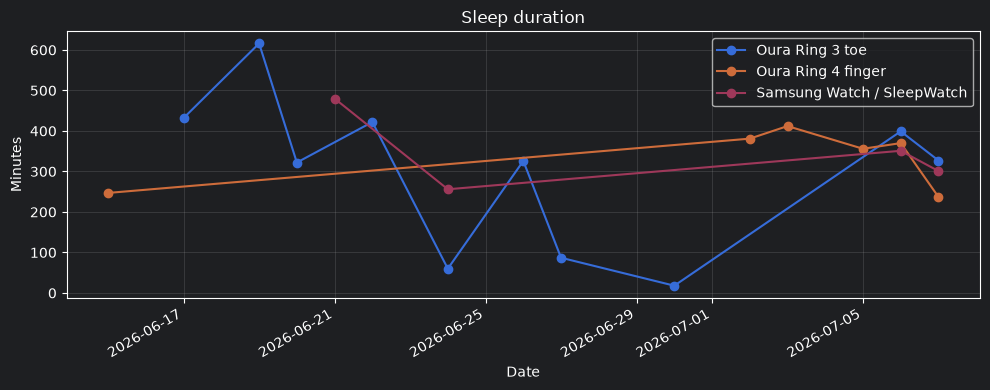

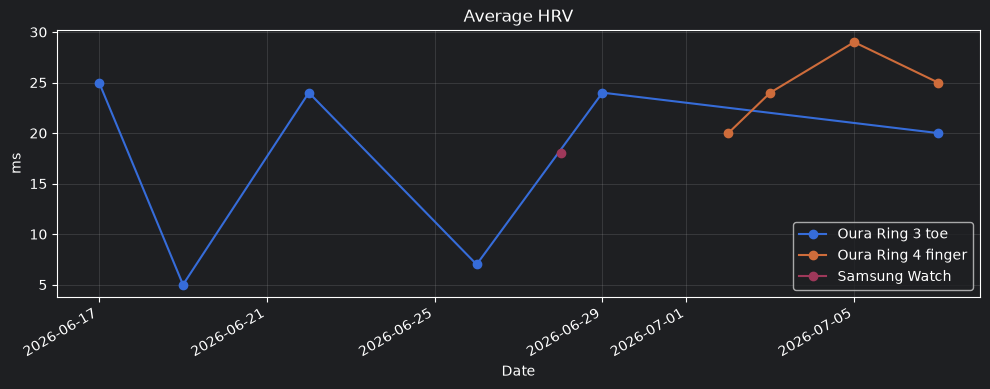

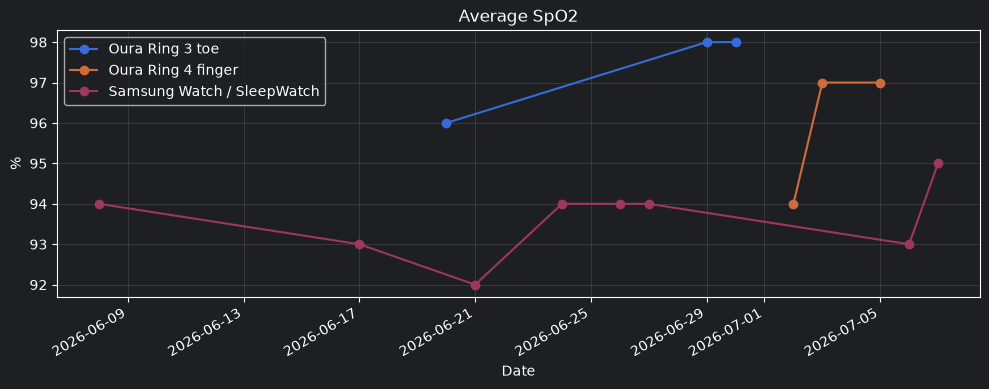

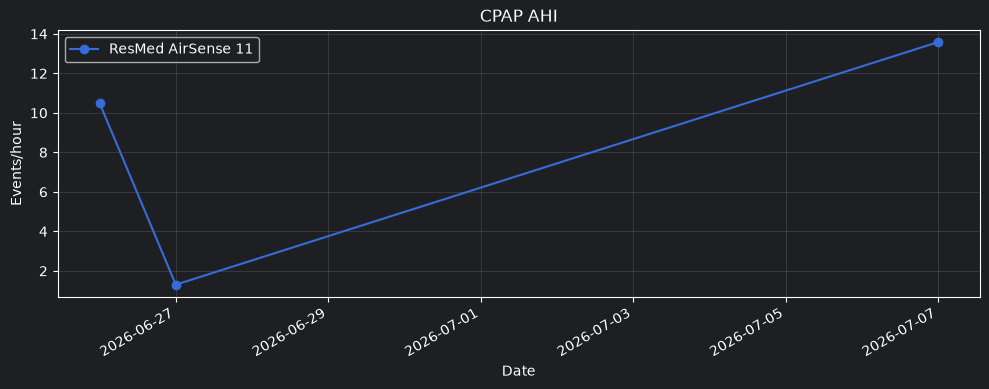

In [7]:
available_metrics = available_numeric_metrics(nightly_summary)
for metric in PLOT_METRICS:
    if metric in OPTIONAL_PLOT_METRICS and metric not in available_metrics:
        print(f"No CPAP metrics detected; skipping optional {metric} trend.")
        continue
    ylabel, title = PLOT_SPECS.get(metric, (CANONICAL_METRIC_UNITS.get(metric, "Value"), metric))
    plot_metric(nightly_summary, metric, ylabel, title)
plt.show()

## Extraction Report

In [8]:
if report_path.exists():
    print(report_path.read_text(encoding="utf-8"))
else:
    print("No extraction report found yet.")

# SleepPy Extraction Report

This report summarizes automated first-pass extraction from screenshots and PDFs.

This is exploratory wellness data analysis only. It is not medical diagnosis, treatment advice, or a replacement for clinician review.

- Night/device rows: 34
- Extracted values: 228

## Values By Device

- Oura Ring 3 toe: 85
- Oura Ring 4 finger: 81
- ResMed AirSense 11: 6
- Samsung Watch: 1
- Samsung Watch / SleepWatch: 55

## Canonical Metrics Available

- total_sleep_minutes
- time_in_bed_minutes
- sleep_efficiency_pct
- sleep_score
- avg_hr_bpm
- min_hr_bpm
- avg_hrv_ms
- avg_spo2_pct
- respiratory_rate_bpm
- cpap_ahi
- cpap_usage_hours
- cpap_leak_rate
- awake_minutes
- rem_minutes
- light_minutes
- deep_minutes
- breathing_label

## Confidence By Device

- Oura Ring 3 toe: high = 11
- Oura Ring 3 toe: low = 1
- Oura Ring 3 toe: medium = 73
- Oura Ring 4 finger: high = 78
- Oura Ring 4 finger: manual = 3
- ResMed AirSense 11: high = 4
- ResMed AirSense 11: medium = 2


## TODO: True CSV/JSON Imports

The current pipeline is for screenshots and PDFs. Add source-specific importers later for native exports, returning the same long-form observation schema used by `device_observations_long.csv`.

In [9]:
# TODO: Add Oura CSV/JSON import for Ring 4 finger and Ring 3 toe exports.
def load_oura_export(path):
    raise NotImplementedError("Parse Oura native exports into normalized observations.")


# TODO: Add Samsung Health / SleepWatch import.
def load_samsung_sleepwatch_export(path):
    raise NotImplementedError("Parse Samsung/SleepWatch native exports into normalized observations.")


# TODO: Add Muse native export or PDF table import.
def load_muse_export(path):
    raise NotImplementedError("Parse Muse exports into normalized observations.")


# TODO: Add OSCAR and SleepScope structured export import.
def load_cpap_export(path):
    raise NotImplementedError("Parse OSCAR/SleepScope exports into normalized observations.")